# Save the data in the right format

In [45]:
import numpy as np
import h5py
from scipy import ndimage
import os
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from dataset import SuperResolutionDataset
import torch.nn as nn
import torch.optim as optim
import time

import torchmetrics
from skimage.metrics import structural_similarity as ssim


import wandb



# Dataloader that works with the hdf5 and can load both lr/hr for training and only lr for inference

In [7]:
# Load Training Dataset (for checking shape)
train_dataset = SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Get a batch for training
lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 20, 20)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 34, 34)

# Load Test Dataset (for evaluation)
test_dataset = SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Get a batch for inference (only LR images)
lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 20, 20)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 34, 34)


Training Mode:
LR Batch Shape: torch.Size([16, 1, 20, 20])
HR Batch Shape: torch.Size([16, 1, 34, 34])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 20, 20])
HR Batch Shape: torch.Size([16, 1, 34, 34])


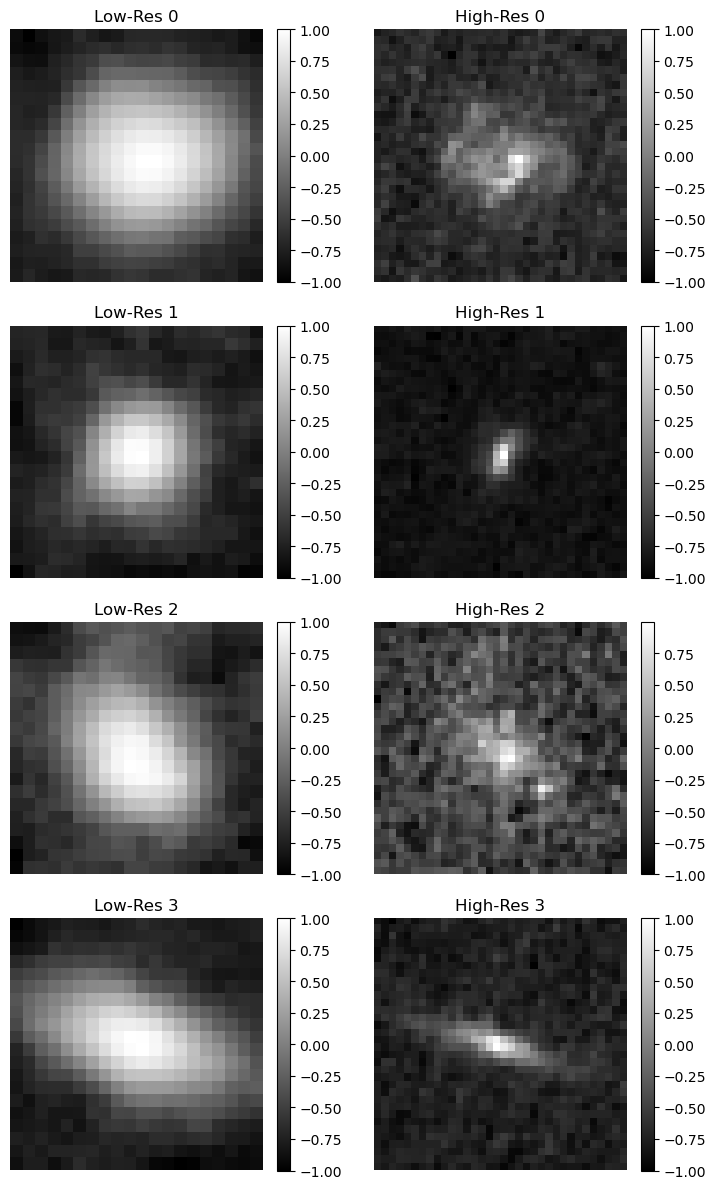

In [9]:
# Define dataset paths
lr_hdf5_path = "../data/Nisp_train.hdf5"
hr_hdf5_path = "../data/Nircam_train.hdf5"

# Load Training Dataset (set split="train" explicitly)
train_dataset = SuperResolutionDataset(lr_hdf5_path, hr_hdf5_path, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Fetch a batch from the training dataset
lr_batch, hr_batch = next(iter(train_loader))

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.squeeze().cpu().numpy()  # Shape: (16, 20, 20)
hr_batch_np = hr_batch.squeeze().cpu().numpy()  # Shape: (16, 34, 34)

# Plot first 4 samples
fig, axes = plt.subplots(4, 2, figsize=(8, 12))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)  # Add colorbar

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()
plt.show()


# Diffusion based model

In [12]:
# UNet with Cross-Attention
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim * 2, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 3, padding=1, stride=2),
            nn.ReLU(),
        )

        # Ensure condition matches x channels
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, kernel_size=3, padding=1)

        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim * 4, num_heads=4)

        # **Corrected Decoder to Maintain 34x34 Output**
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=3, stride=2, padding=1, output_padding=0),  # Prevent extra expansion
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=3, stride=2, padding=1, output_padding=1),  # Expands to exactly 34
            nn.ReLU(),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1),  # Keeps final size at 34x34
        )

    def forward(self, x, condition):
        x = self.encoder(x)
        condition = self.condition_proj(condition)  # Match channel dimension

        batch_size, channels, height, width = x.shape

        # Flatten height & width dimensions before attention
        x = x.flatten(2).permute(2, 0, 1)  # (seq_len, batch, embed_dim)
        condition = condition.flatten(2).permute(2, 0, 1)

        x, _ = self.cross_attention(x, condition, condition)  # Apply attention

        # Reshape back to image format
        x = x.permute(1, 2, 0).view(batch_size, channels, height, width)
        x = self.decoder(x)
        return x

# Diffusion Model
class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=1000):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps

    def forward(self, x, t, condition):
        return self.unet(x, condition)

# **Corrected Upsampler for 20x20 -> 34x34**
class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.upsample = nn.Upsample(size=(34, 34), mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)  # Keep padding=1

    def forward(self, x):
        x = self.upsample(x)
        return self.conv(x)

# Full Model
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        upscaled = self.upsampler(x)  # 20x20 -> 34x34

        # Add progressive noise instead of replacing
        noise = torch.randn_like(upscaled)
        alpha_t = torch.sqrt(1 - (t / self.diffusion.timesteps).float().view(-1, 1, 1, 1))
        noisy_image = alpha_t * upscaled + (1 - alpha_t) * noise

        return self.diffusion(noisy_image, t, upscaled)

# Instantiate models
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1)  
upsampler = Upsampler()
model = SuperResolutionDiffusion(unet, upsampler)

# Example input
x = torch.randn(1, 1, 20, 20)  # Low-res input
t = torch.tensor([500])  # Midpoint timestep in diffusion
output = model(x, t)

print("Output shape:", output.shape)  


Output shape: torch.Size([1, 1, 34, 34])


# Train

In [27]:
# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = 5

# Train-Test Dataloaders
train_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="train"),
    batch_size=8, shuffle=True, num_workers=4 
)
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
    batch_size=8, shuffle=False, num_workers=4
)

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    print(f"Starting Epoch {epoch+1}...")  # ✅ Debugging print

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):

        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)
        
        output = model(lr_batch, t)# Forward pass
        loss = criterion(output, hr_batch)# Compute loss
        epoch_loss += loss.item()
        
        optimizer.zero_grad()# Backpropagation
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

# Save trained model
torch.save(model.state_dict(), "super_resolution_model.pth")
print("Model saved successfully!")


Starting Epoch 1...
Epoch [1/5], Loss: 0.055404, Time: 191.97s
Starting Epoch 2...
Epoch [2/5], Loss: 0.054080, Time: 194.16s
Starting Epoch 3...
Epoch [3/5], Loss: 0.052692, Time: 195.70s
Starting Epoch 4...
Epoch [4/5], Loss: 0.051992, Time: 192.97s
Starting Epoch 5...
Epoch [5/5], Loss: 0.051206, Time: 196.77s
Model saved successfully!


# Evaluate 

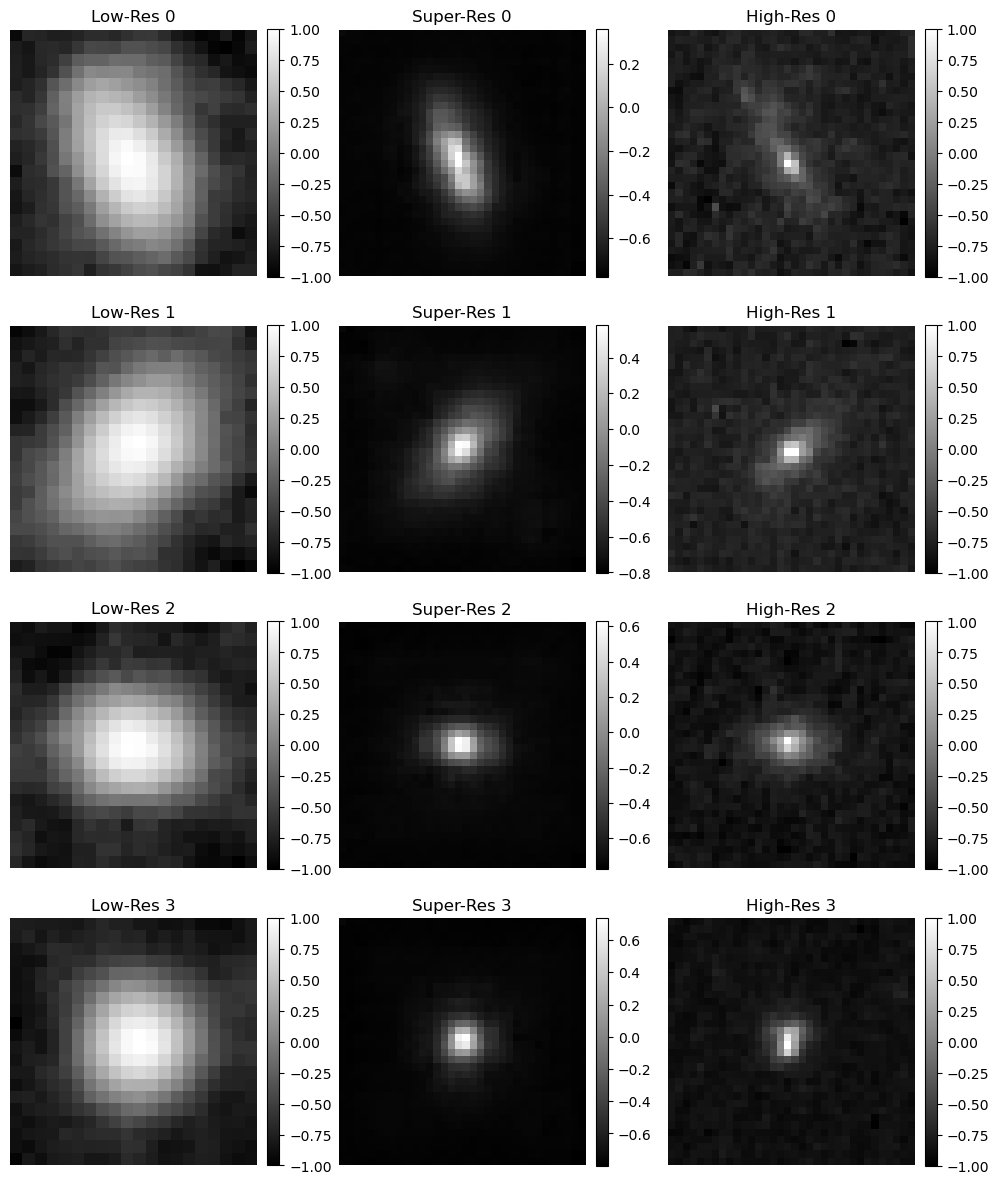

In [39]:
# Set model to evaluation mode
model.eval()


# Fetch a test batch from `test_loader`
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
    batch_size=16, shuffle=False, num_workers=0
)

import random

# Convert test_loader into a list and randomly pick one batch
test_batches = list(test_loader)
random_batch_idx = random.randint(0, len(test_batches) - 1)
lr_batch, hr_batch = test_batches[random_batch_idx] 
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# Pick a few images to visualize
num_images = min(4, lr_batch.shape[0])  # Ensure we don't exceed batch size
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

# Generate super-resolution (SR) images
with torch.no_grad():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # Set t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test).cpu()  # Super-resolved output

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.cpu().squeeze().numpy()  # (batch, 20, 20)
sr_batch_np = sr_batch.cpu().squeeze().numpy()  # (batch, 34, 34)
hr_batch_np = hr_batch.cpu().squeeze().numpy()  # (batch, 34, 34)

# Plot results
for i in range(num_images):
    # Low-Resolution Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved Image
    img2 = axes[i, 1].imshow(sr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"Super-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Resolution Image (Ground Truth)
    img3 = axes[i, 2].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [47]:
# PSNR function using torchmetrics
def compute_psnr(pred, target):
    psnr = torchmetrics.functional.image.peak_signal_noise_ratio(pred, target)
    return psnr.item()

# SSIM function using skimage
def compute_ssim(pred, target):
    pred_np = pred.squeeze().cpu().numpy()
    target_np = target.squeeze().cpu().numpy()
    return ssim(pred_np, target_np, data_range=target_np.max() - target_np.min())

# Set model to evaluation mode
model.eval()

# Fetch a test batch from test_loader
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
    batch_size=1, shuffle=True, num_workers=0  # ✅ Ensures we evaluate on random test samples
)

lr_test, hr_test = next(iter(test_loader))  # ✅ Proper test sample selection
lr_test, hr_test = lr_test.to(device), hr_test.to(device)

# Generate super-resolution image
with torch.no_grad():
    t_test = torch.tensor([0], device=device)  # At t=0 for final reconstruction
    predicted_hr = model(lr_test, t_test).cpu()  # Move result to CPU

# Compute PSNR & SSIM
psnr_value = compute_psnr(predicted_hr, hr_test.cpu())
ssim_value = compute_ssim(predicted_hr, hr_test.cpu())

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.3f}")


PSNR: 19.67 dB
SSIM: 0.900


# with W&B

In [ ]:
# Initialize Weights & Biases
wandb.init(
    project="super-resolution-diffusion",
    config={
        "epochs": 10,
        "learning_rate": 1e-4,
        "batch_size": 16,
        "optimizer": "AdamW",
        "loss_function": "MSELoss"
    }
)

# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = wandb.config["epochs"]

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for lr_batch, hr_batch in dataloader:
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

        # Pick random timesteps for diffusion
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)

        # Forward pass
        output = model(lr_batch, t)

        # Compute loss
        loss = criterion(output, hr_batch)
        epoch_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(dataloader)
    elapsed_time = time.time() - start_time

    # Log to WandB
    wandb.log({
        "epoch": epoch + 1,
        "loss": avg_loss,
        "time_per_epoch": elapsed_time
    })

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

# Finish WandB logging
wandb.finish()


In [ ]:
# Set model to evaluation mode
model.eval()

# Fetch a test batch
lr_batch, hr_batch = next(iter(test_loader))  # Use test dataset
lr_batch = lr_batch.to(device)

# Generate super-resolution (SR) images
with torch.no_grad():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # Set t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test).cpu()  # Super-resolved output

# Select a few images for logging
num_samples = 4
for i in range(num_samples):
    # Convert tensors to NumPy for visualization
    lr_img = lr_batch[i].squeeze().cpu().numpy()
    sr_img = sr_batch[i].squeeze().cpu().numpy()
    hr_img = hr_batch[i].squeeze().cpu().numpy()

    # Log images to WandB
    wandb.log({
        f"Low-Res-{i}": wandb.Image(lr_img, caption="Low-Resolution"),
        f"Super-Res-{i}": wandb.Image(sr_img, caption="Super-Resolution"),
        f"High-Res-{i}": wandb.Image(hr_img, caption="Ground Truth")
    })

wandb.finish()
